<a href="https://colab.research.google.com/github/lauria02/my-colab-projects/blob/main/EDA_jobs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving job_postings_flat.csv to job_postings_flat.csv


In [ ]:
import pandas as pd

df = pd.read_csv("job_postings_flat.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478895 entries, 0 to 478894
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        478895 non-null  object        
 1   job_title              478894 non-null  object        
 2   job_location           477522 non-null  object        
 3   job_via                478889 non-null  object        
 4   job_schedule_type      470983 non-null  object        
 5   job_work_from_home     478895 non-null  bool          
 6   search_location        478895 non-null  object        
 7   job_posted_date        193050 non-null  datetime64[ns]
 8   job_no_degree_mention  478895 non-null  bool          
 9   job_health_insurance   478895 non-null  bool          
 10  job_country            478574 non-null  object        
 11  salary_rate            30411 non-null   object        
 12  salary_year_avg        20335 non-null   floa

In [ ]:
df.size

8141215

In [ ]:
df.shape

(478895, 17)

In [ ]:
df['job_posted_date'].head(10)

,job_posted_date
0,01-01-2024 00:00
1,01-01-2024 00:00
2,01-01-2024 00:00
3,01-01-2024 00:00
4,01-01-2024 00:00
5,01-01-2024 00:00
6,01-01-2024 00:00
7,01-01-2024 00:00
8,01-01-2024 00:00
9,01-01-2024 00:01


In [ ]:
df['job_posted_date'] = pd.to_datetime(
    df['job_posted_date'],
    errors='coerce'
)

In [ ]:
df['job_posted_date'].isna().sum()

np.int64(285845)

In [1]:
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

NameError: name 'df' is not defined

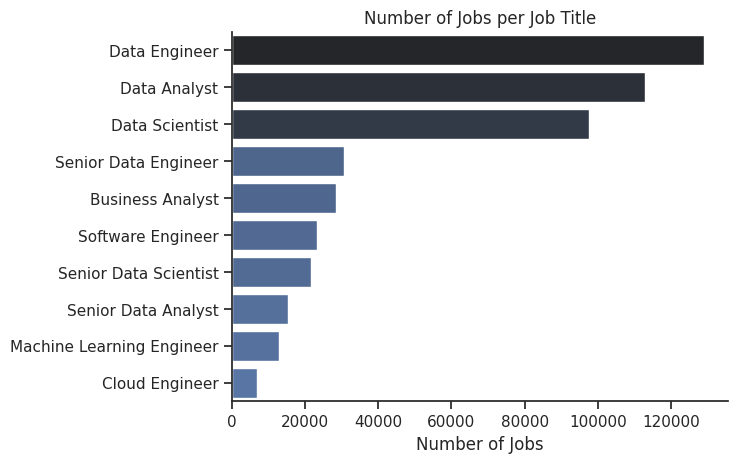

In [ ]:
df_plot = df['job_title_short'].value_counts().to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

Countries to Explore


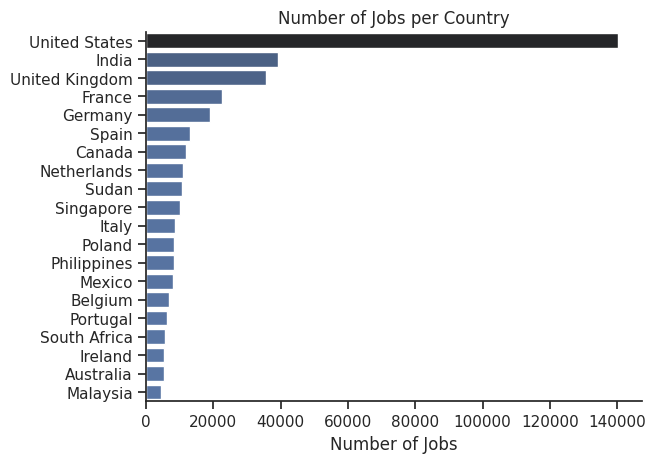

In [ ]:
df_plot = df['job_country'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Country')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Companies to Explore

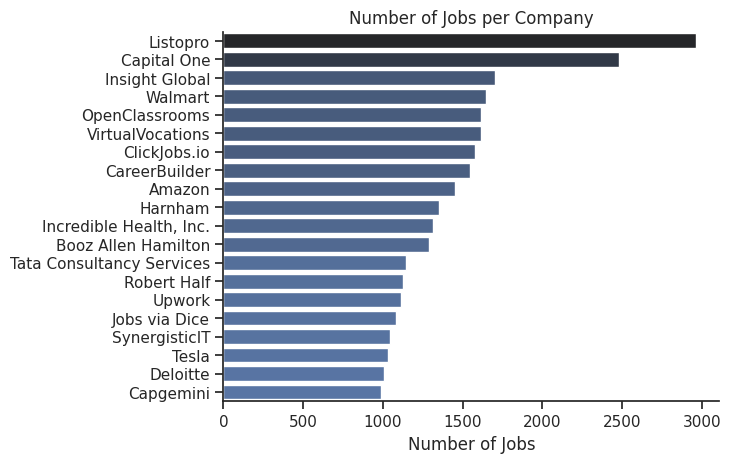

In [ ]:
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

Job Opportunities

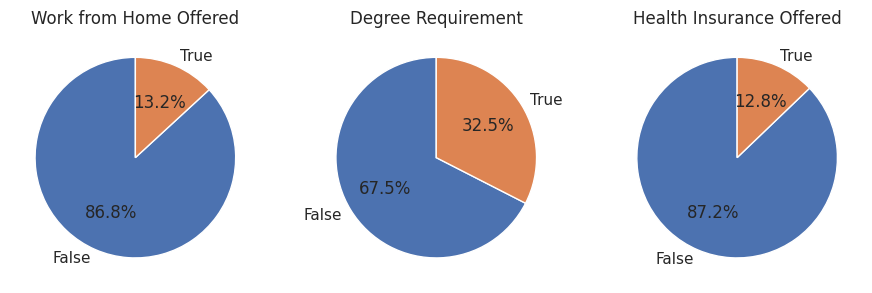

In [ ]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

Exploratory Data Analysis for Data Analysts in the US

Filter for US Data Analyst roles

In [ ]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

Locations to Explore:

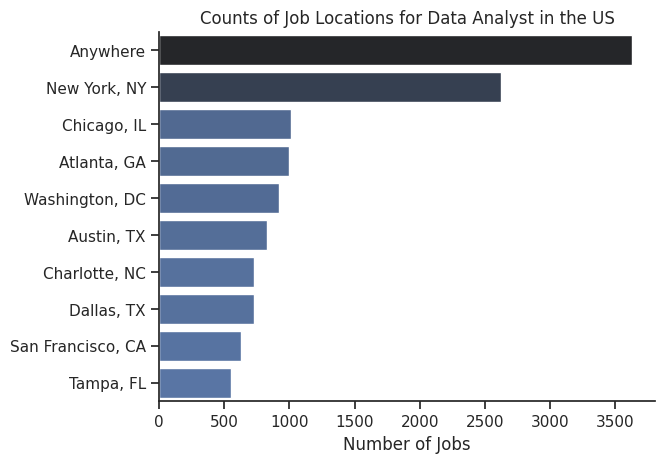

In [ ]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

Job Opportunities


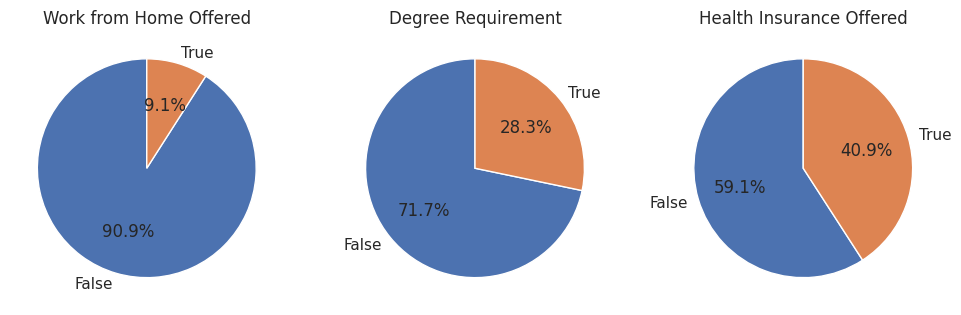

In [ ]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

# plt.suptitle('Benefit Analysis of Data Jobs', fontsize=16)
plt.show()

Companies to Explore:

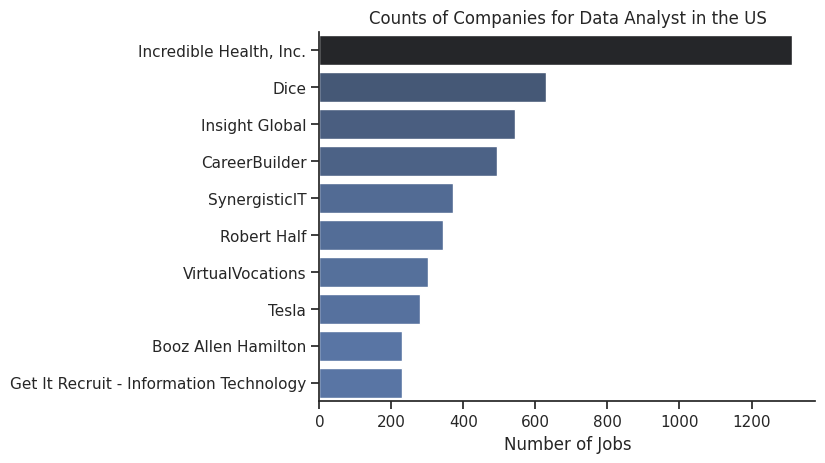

In [ ]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()